# Smartphone User Behavior Analysis

## 1. Problem Statement

- With the rapid growth of smartphone usage, understanding user interaction patterns has become important for companies developing mobile applications and digital services.

- Raw datasets often contain limited information and cannot directly provide meaningful insights or predictive power. Feature engineering transforms raw variables into meaningful features that help improve analysis and machine learning models.

## 2. Objectives

To explore smartphone user behavior data.

To perform data preprocessing and cleaning.

To apply feature engineering techniques on raw features.

To create meaningful new variables from existing data.

To analyze relationships between engineered features.

To prepare the dataset for machine learning models.

## 3. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 4. Load Dataset

In [5]:
df = pd.read_csv("smartphoneUsage_dataset.csv")

df.head(10)

,user_id,age,daily_screen_time_hours,num_apps_used_daily,avg_session_minutes,notifications_per_day,data_usage_mb_per_day,device_storage_gb,battery_capacity_mah,primary_app_category
0,1,56,1.33,22,35.41,114,693.13,128,5000,Gaming
1,2,46,3.27,33,11.82,80,822.85,256,3500,Shopping
2,3,32,7.42,29,22.67,114,769.39,128,5000,Education
3,4,25,9.06,11,26.17,22,343.81,64,3000,Shopping
4,5,38,5.61,28,10.40,91,1255.56,512,3500,Social Media
5,6,56,5.79,19,39.18,110,1885.29,128,3000,Education
6,7,36,1.96,15,30.43,22,1595.48,512,3500,Gaming
7,8,40,5.03,22,23.20,109,1747.60,256,5000,Education
8,9,28,5.79,27,8.86,40,386.64,256,4500,Social Media
9,10,28,3.18,16,4.05,11,2388.43,64,4000,Entertainment


## 5. Basic Dataset Exploration

In [6]:
df.shape

(800, 10)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  800 non-null    int64  
 1   age                      800 non-null    int64  
 2   daily_screen_time_hours  800 non-null    float64
 3   num_apps_used_daily      800 non-null    int64  
 4   avg_session_minutes      800 non-null    float64
 5   notifications_per_day    800 non-null    int64  
 6   data_usage_mb_per_day    800 non-null    float64
 7   device_storage_gb        800 non-null    int64  
 8   battery_capacity_mah     800 non-null    int64  
 9   primary_app_category     800 non-null    str    
dtypes: float64(3), int64(6), str(1)
memory usage: 70.3 KB


In [10]:
df.describe()

,user_id,age,daily_screen_time_hours,num_apps_used_daily,avg_session_minutes,notifications_per_day,data_usage_mb_per_day,device_storage_gb,battery_capacity_mah
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,38.802500,5.463650,19.208750,20.964538,64.973750,1341.978063,246.480000,3963.125000
std,231.0844,12.055919,2.639516,8.668859,11.104049,31.532657,654.622167,171.767312,716.917148
min,1.0000,18.000000,1.040000,5.000000,2.010000,10.000000,201.500000,64.000000,3000.000000
25%,200.7500,29.000000,3.090000,12.000000,10.927500,37.000000,768.870000,128.000000,3500.000000
50%,400.5000,40.000000,5.485000,19.000000,21.410000,65.000000,1331.215000,256.000000,4000.000000
75%,600.2500,49.000000,7.735000,26.250000,30.500000,93.000000,1920.920000,512.000000,4500.000000
max,800.0000,59.000000,9.980000,34.000000,39.990000,119.000000,2498.980000,512.000000,5000.000000


## 6. Check Missing Values

In [11]:
df.isnull().sum()

user_id                    0
age                        0
daily_screen_time_hours    0
num_apps_used_daily        0
avg_session_minutes        0
notifications_per_day      0
data_usage_mb_per_day      0
device_storage_gb          0
battery_capacity_mah       0
primary_app_category       0
dtype: int64

## 7. Feature Engineering Techniques

### 7.1 Screen Time Category

Convert continuous values into categorical groups.

In [13]:
df["screen_time_category"] = pd.cut(
    df["daily_screen_time_hours"],
    bins=[0,3,6,12],
    labels=["Low","Medium","High"]
)

df.head()

,user_id,age,daily_screen_time_hours,num_apps_used_daily,avg_session_minutes,notifications_per_day,data_usage_mb_per_day,device_storage_gb,battery_capacity_mah,primary_app_category,screen_time_category
0,1,56,1.33,22,35.41,114,693.13,128,5000,Gaming,Low
1,2,46,3.27,33,11.82,80,822.85,256,3500,Shopping,Medium
2,3,32,7.42,29,22.67,114,769.39,128,5000,Education,High
3,4,25,9.06,11,26.17,22,343.81,64,3000,Shopping,High
4,5,38,5.61,28,10.40,91,1255.56,512,3500,Social Media,Medium


## 7.2 Notifications per App

Measure engagement intensity.

In [15]:
df["notifications_per_app"] = df["notifications_per_day"] / df["num_apps_used_daily"]

df.head()


,user_id,age,daily_screen_time_hours,num_apps_used_daily,avg_session_minutes,notifications_per_day,data_usage_mb_per_day,device_storage_gb,battery_capacity_mah,primary_app_category,screen_time_category,notifications_per_app
0,1,56,1.33,22,35.41,114,693.13,128,5000,Gaming,Low,5.181818
1,2,46,3.27,33,11.82,80,822.85,256,3500,Shopping,Medium,2.424242
2,3,32,7.42,29,22.67,114,769.39,128,5000,Education,High,3.931034
3,4,25,9.06,11,26.17,22,343.81,64,3000,Shopping,High,2.000000
4,5,38,5.61,28,10.40,91,1255.56,512,3500,Social Media,Medium,3.250000


## 7.3 Data Usage per Hour

Shows internet consumption rate.

In [17]:
df["data_per_hour"] = df["data_usage_mb_per_day"] / df["daily_screen_time_hours"]
df.head()

,user_id,age,daily_screen_time_hours,num_apps_used_daily,avg_session_minutes,notifications_per_day,data_usage_mb_per_day,device_storage_gb,battery_capacity_mah,primary_app_category,screen_time_category,notifications_per_app,data_per_hour
0,1,56,1.33,22,35.41,114,693.13,128,5000,Gaming,Low,5.181818,521.150376
1,2,46,3.27,33,11.82,80,822.85,256,3500,Shopping,Medium,2.424242,251.636086
2,3,32,7.42,29,22.67,114,769.39,128,5000,Education,High,3.931034,103.691375
3,4,25,9.06,11,26.17,22,343.81,64,3000,Shopping,High,2.000000,37.948124
4,5,38,5.61,28,10.40,91,1255.56,512,3500,Social Media,Medium,3.250000,223.807487


## 7.4 Battery Usage Efficiency

Estimate battery consumption relative to screen usage.

In [18]:
df["battery_efficiency"] = df["battery_capacity_mah"] / df["daily_screen_time_hours"]
df.head()

,user_id,age,daily_screen_time_hours,num_apps_used_daily,avg_session_minutes,notifications_per_day,data_usage_mb_per_day,device_storage_gb,battery_capacity_mah,primary_app_category,screen_time_category,notifications_per_app,data_per_hour,battery_efficiency
0,1,56,1.33,22,35.41,114,693.13,128,5000,Gaming,Low,5.181818,521.150376,3759.398496
1,2,46,3.27,33,11.82,80,822.85,256,3500,Shopping,Medium,2.424242,251.636086,1070.336391
2,3,32,7.42,29,22.67,114,769.39,128,5000,Education,High,3.931034,103.691375,673.854447
3,4,25,9.06,11,26.17,22,343.81,64,3000,Shopping,High,2.000000,37.948124,331.125828
4,5,38,5.61,28,10.40,91,1255.56,512,3500,Social Media,Medium,3.250000,223.807487,623.885918


## 7.5 Session Intensity

Measures user engagement strength.

In [20]:
df["session_intensity"] = df["avg_session_minutes"] * df["num_apps_used_daily"]
df.head()

,user_id,age,daily_screen_time_hours,num_apps_used_daily,avg_session_minutes,notifications_per_day,data_usage_mb_per_day,device_storage_gb,battery_capacity_mah,primary_app_category,screen_time_category,notifications_per_app,data_per_hour,battery_efficiency,session_intensity
0,1,56,1.33,22,35.41,114,693.13,128,5000,Gaming,Low,5.181818,521.150376,3759.398496,779.02
1,2,46,3.27,33,11.82,80,822.85,256,3500,Shopping,Medium,2.424242,251.636086,1070.336391,390.06
2,3,32,7.42,29,22.67,114,769.39,128,5000,Education,High,3.931034,103.691375,673.854447,657.43
3,4,25,9.06,11,26.17,22,343.81,64,3000,Shopping,High,2.000000,37.948124,331.125828,287.87
4,5,38,5.61,28,10.40,91,1255.56,512,3500,Social Media,Medium,3.250000,223.807487,623.885918,291.20


## 7.6 Storage Category

In [21]:
df["storage_category"] = pd.cut(
    df["device_storage_gb"],
    bins=[0,64,128,256,512],
    labels=["Very Low","Low","Medium","High"]
)

df.head()

,user_id,age,daily_screen_time_hours,num_apps_used_daily,avg_session_minutes,notifications_per_day,data_usage_mb_per_day,device_storage_gb,battery_capacity_mah,primary_app_category,screen_time_category,notifications_per_app,data_per_hour,battery_efficiency,session_intensity,storage_category
0,1,56,1.33,22,35.41,114,693.13,128,5000,Gaming,Low,5.181818,521.150376,3759.398496,779.02,Low
1,2,46,3.27,33,11.82,80,822.85,256,3500,Shopping,Medium,2.424242,251.636086,1070.336391,390.06,Medium
2,3,32,7.42,29,22.67,114,769.39,128,5000,Education,High,3.931034,103.691375,673.854447,657.43,Low
3,4,25,9.06,11,26.17,22,343.81,64,3000,Shopping,High,2.000000,37.948124,331.125828,287.87,Very Low
4,5,38,5.61,28,10.40,91,1255.56,512,3500,Social Media,Medium,3.250000,223.807487,623.885918,291.20,High


## 7.7 Notification Load

In [22]:
df["notification_load"] = df["notifications_per_day"] / df["daily_screen_time_hours"]
df.head()

,user_id,age,daily_screen_time_hours,num_apps_used_daily,avg_session_minutes,notifications_per_day,data_usage_mb_per_day,device_storage_gb,battery_capacity_mah,primary_app_category,screen_time_category,notifications_per_app,data_per_hour,battery_efficiency,session_intensity,storage_category,notification_load
0,1,56,1.33,22,35.41,114,693.13,128,5000,Gaming,Low,5.181818,521.150376,3759.398496,779.02,Low,85.714286
1,2,46,3.27,33,11.82,80,822.85,256,3500,Shopping,Medium,2.424242,251.636086,1070.336391,390.06,Medium,24.464832
2,3,32,7.42,29,22.67,114,769.39,128,5000,Education,High,3.931034,103.691375,673.854447,657.43,Low,15.363881
3,4,25,9.06,11,26.17,22,343.81,64,3000,Shopping,High,2.000000,37.948124,331.125828,287.87,Very Low,2.428256
4,5,38,5.61,28,10.40,91,1255.56,512,3500,Social Media,Medium,3.250000,223.807487,623.885918,291.20,High,16.221034


## 7.8 Age Group Feature

In [25]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[18,25,35,45,60],
    labels=["Young","Adult","Mid-Age","Senior"]
)
df.head()

,user_id,age,daily_screen_time_hours,num_apps_used_daily,avg_session_minutes,notifications_per_day,data_usage_mb_per_day,device_storage_gb,battery_capacity_mah,primary_app_category,screen_time_category,notifications_per_app,data_per_hour,battery_efficiency,session_intensity,storage_category,notification_load,age_group
0,1,56,1.33,22,35.41,114,693.13,128,5000,Gaming,Low,5.181818,521.150376,3759.398496,779.02,Low,85.714286,Senior
1,2,46,3.27,33,11.82,80,822.85,256,3500,Shopping,Medium,2.424242,251.636086,1070.336391,390.06,Medium,24.464832,Senior
2,3,32,7.42,29,22.67,114,769.39,128,5000,Education,High,3.931034,103.691375,673.854447,657.43,Low,15.363881,Adult
3,4,25,9.06,11,26.17,22,343.81,64,3000,Shopping,High,2.000000,37.948124,331.125828,287.87,Very Low,2.428256,Young
4,5,38,5.61,28,10.40,91,1255.56,512,3500,Social Media,Medium,3.250000,223.807487,623.885918,291.20,High,16.221034,Mid-Age


## 7.9 Data Usage Category

In [26]:
df["data_usage_category"] = pd.cut(
    df["data_usage_mb_per_day"],
    bins=[0,800,1500,3000],
    labels=["Low","Medium","High"]
)

# 8. Visualization of Engineered Features

Screen Time Distribution

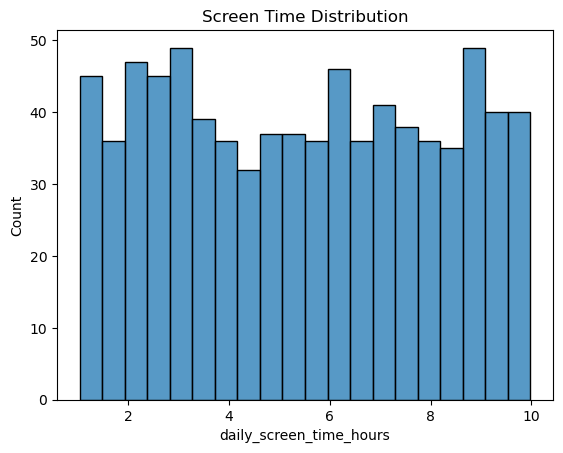

In [27]:
sns.histplot(df["daily_screen_time_hours"], bins=20)
plt.title("Screen Time Distribution")
plt.show()

Screen Time Category Count

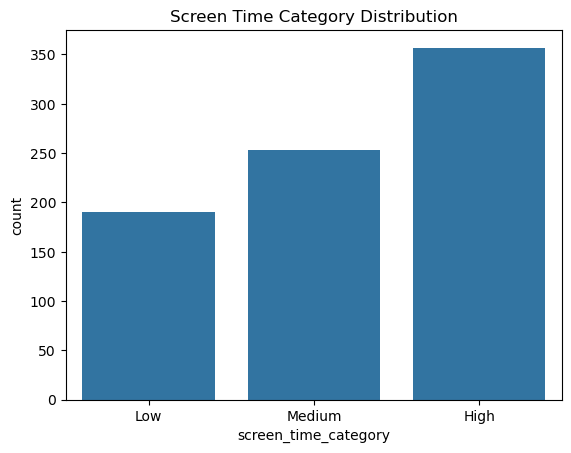

In [28]:
sns.countplot(x="screen_time_category", data=df)
plt.title("Screen Time Category Distribution")
plt.show()

Age Group vs Screen Time

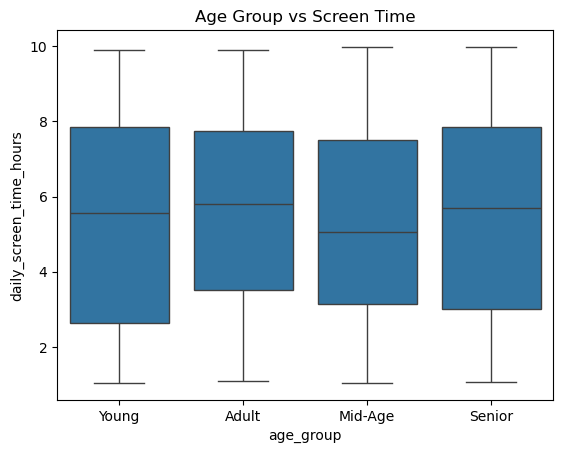

In [29]:
sns.boxplot(x="age_group", y="daily_screen_time_hours", data=df)
plt.title("Age Group vs Screen Time")
plt.show()

Session Intensity Distribution

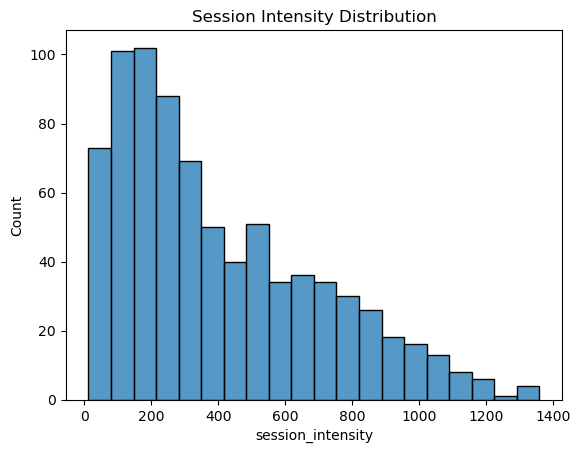

In [30]:
sns.histplot(df["session_intensity"], bins=20)
plt.title("Session Intensity Distribution")
plt.show()

# 9. Correlation Analysis

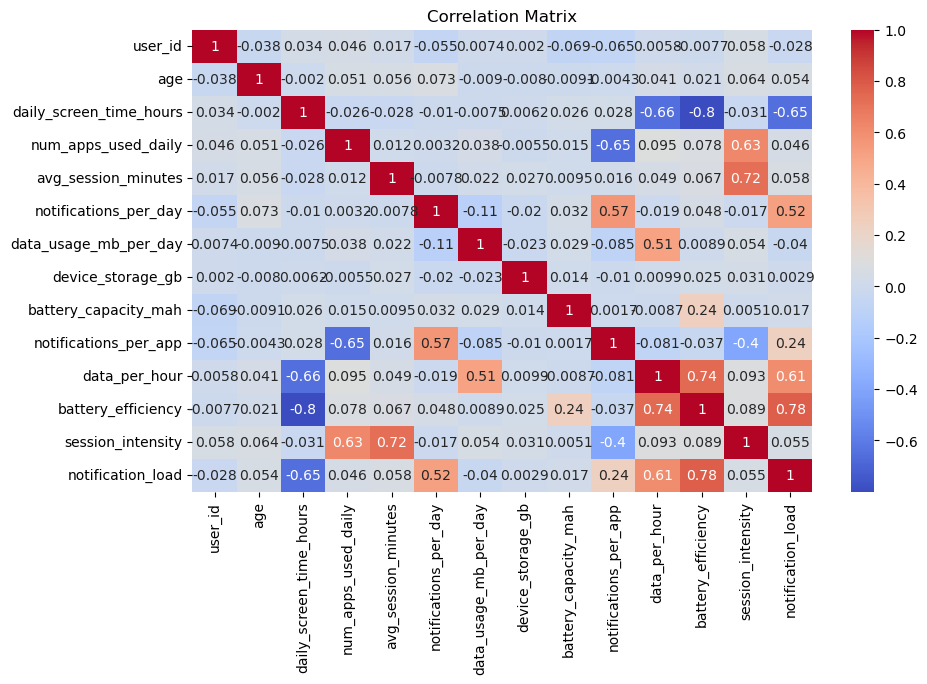

In [31]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# 10.Insights

- Users with higher screen time generally receive more notifications.

- Gaming and social media users tend to have higher session intensity.

- Younger users show higher data usage patterns.

- Notification load is strongly related to screen engagement.

- Devices with larger storage tend to show higher app usage.

# 11. Conclusion

This project demonstrated how feature engineering can transform raw smartphone usage data into meaningful insights.

New features such as session intensity, notification load, and data usage per hour provided deeper understanding of user behavior patterns.

Feature engineering plays a crucial role in preparing datasets for machine learning models by improving predictive power and interpretability.